### Этап 1. Сбор и подготовка данных
#### Загрузка и обработка данных

In [4]:
from src.data_utils import PrepareData
data=PrepareData('data/tweets.txt',100000)

Все тексты: 99190
["a that's a bummer you shoulda got david carr of third day to do it d", "is upset that he can't update his facebook by texting it and might cry as a result school today also blah"]
Размеры:  79352 9919 9919


#### Токенизация, кодирование и сохранение токенов в файл
Разделение входных и целевых данных происходит по принципу y=x[1:]

In [5]:
from src.data_utils import prepare_tokenized
prepare_tokenized('data/texts_tokenized.pt')

79352 9919 9919


#### Загрузка токенизирвоанных данных

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from src.data_utils import TextDataset

data=torch.load('data/texts_tokenized.pt',weights_only=False)
print("Loaded: ",len(data['train_ds']),len(data['val_ds']),len(data['test_ds']))
train_loader = DataLoader(data['train_ds'], batch_size=128, shuffle=True)
val_loader = DataLoader(data['val_ds'], batch_size=128, shuffle=False)
test_loader = DataLoader(data['test_ds'], batch_size=64, shuffle=False)

Loaded:  79352 9919 9919


### Этап 2. Объявление модели
#### Создание модели

In [5]:
from src.lstm_model import MyRNN
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained('distilgpt2')
tokenizer.pad_token = tokenizer.eos_token

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
vocab_size=tokenizer.vocab_size
pad_token_id=tokenizer.pad_token_id
model = MyRNN(vocab_size=vocab_size, embedding_dim=128, hidden_dim=256,padding_idx=pad_token_id).to(device)
print("vocab",vocab_size)
print("pad token",pad_token_id)
print(model)

# # создание оптимизатора и функции потерь
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # создайте оптимайзер с регуляризацией
criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_token_id)


cuda
vocab 50257
pad token 50256
MyRNN(
  (embedding): Embedding(50257, 128, padding_idx=50256)
  (lstm): LSTM(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=50257, bias=True)
)


### Этап 3. Тренировка модели
#### Запуск обучения

100%|██████████| 78/78 [00:14<00:00,  5.38it/s]


Epoch 1: Loss = 6.7249, Val_loss=6.102602530748416, Rouge1 = 0.0622, Rouge2 = 0.0048


100%|██████████| 78/78 [00:14<00:00,  5.44it/s]


Epoch 2: Loss = 5.8322, Val_loss=5.753736550991352, Rouge1 = 0.0686, Rouge2 = 0.0062


100%|██████████| 78/78 [00:14<00:00,  5.41it/s]


...

Epoch 8: Loss = 4.8261, Val_loss=5.381566628431663, Rouge1 = 0.1789, Rouge2 = 0.0244


100%|██████████| 78/78 [00:12<00:00,  6.02it/s]


Epoch 9: Loss = 4.7389, Val_loss=5.379955903077737, Rouge1 = 0.1722, Rouge2 = 0.0230


100%|██████████| 78/78 [00:12<00:00,  6.05it/s]


Epoch 10: Loss = 4.6600, Val_loss=5.3887925637074, Rouge1 = 0.1734, Rouge2 = 0.0241


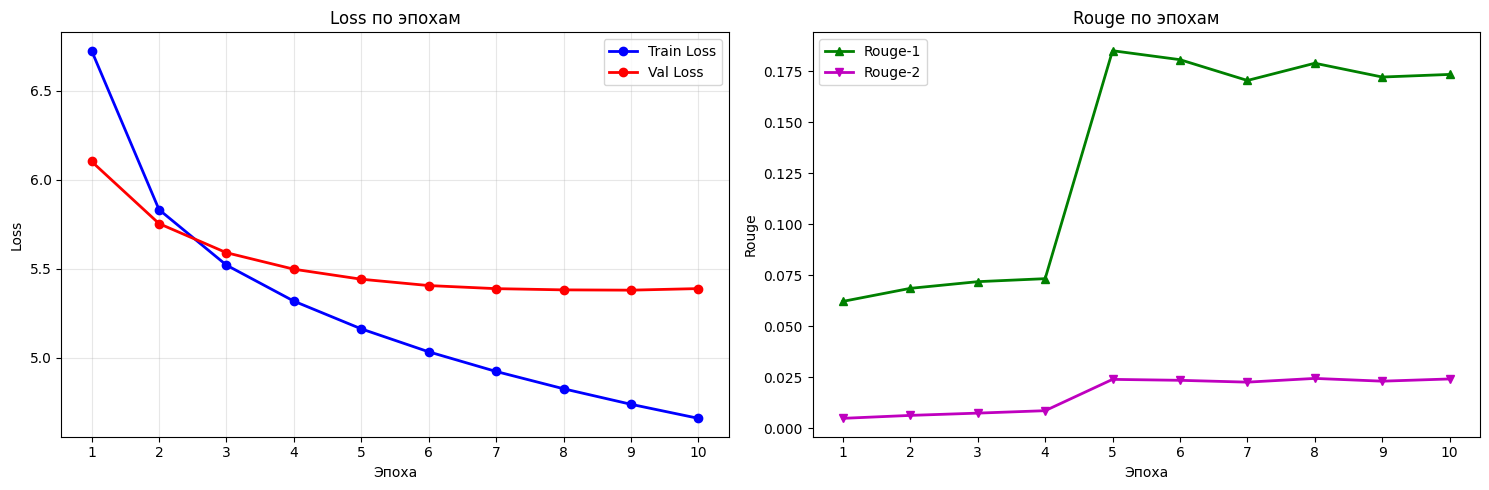

In [11]:
from src.lstm_train import train_epoch, evaluate_train, plot_data

# обучение
train_losses, val_losses = [], []
r1s, r2s = [], []

for epoch in range(10):
    loss = train_epoch(model, train_loader,optimizer,criterion,device,vocab_size)
    val_loss, r1, r2 = evaluate_train(model, val_loader,tokenizer,criterion,device,vocab_size)
    train_losses.append(loss)
    val_losses.append(val_loss)
    r1s.append(r1)
    r2s.append(r2)
    print(f"Epoch {epoch+1}: Loss = {loss:.4f}, Val_loss={val_loss}, Rouge1 = {r1:.4f}, Rouge2 = {r2:.4f}")

plot_data(train_losses,val_losses,r1s,r2s)

#### Сохранение весов

In [12]:
torch.save(model.state_dict(), 'models/model_weights.pth')

#### Тестирвоание на тестовой выборке
Текст делится на 75+25%, первые 2/3 загружаются в модель и генерируется продолжение до размера оригинала.

Затем сравниваются метрики rouge для оригинала и генерированного текста

In [6]:
# load test data
data=torch.load('data/texts_tokenized.pt',weights_only=False)
print("Loaded: ",len(data['test_ds']))
test_loader = DataLoader(data['test_ds'], batch_size=64, shuffle=False)
# load model weights
model.load_state_dict(torch.load('models/model_weights.pth'))

Loaded:  9919


<All keys matched successfully>

In [31]:
from src.eval import generate_autocomplete, eval_on_test

# Вывод примера автодополнения
eval_on_test(model,test_loader,autocomplete=generate_autocomplete,tokenizer=tokenizer,demo=3)

  0%|          | 0/155 [00:00<?, ?it/s]


prompt:  they'd probably be hanged for it i would hope there would be
test:    they'd probably be hanged for it i would hope there would be no slapping going on
gen:     they'd probably be hanged for it i would hope there would be on here today but

prompt:  i suppose i'd better get up then off to see coraline 3d in a bit looks like a missed a fine
test:    i suppose i'd better get up then off to see coraline 3d in a bit looks like a missed a fine morning for archery but noone rang me
gen:     i suppose i'd better get up then off to see coraline 3d in a bit looks like a missed a fine i hate it when i'll be

prompt:  one of the best weekends is
test:    one of the best weekends is about to end
gen:     one of the best weekends is a bummer


(0, 0)

In [26]:
# сравнение тестовых строк с генерированными
r1,r2 = eval_on_test(model,test_loader,autocomplete=generate_autocomplete,tokenizer=tokenizer,demo=-1)
print(f"Rouge1: {r1}, Rouge2: {r2}")

100%|██████████| 155/155 [03:34<00:00,  1.39s/it]

Rouge1: 0.07808731600758288, Rouge2: 0.00838240906381268


### Этап 4. Использование предобученного трансформера

In [30]:
from src.eval_transformer_pipeline import generate_autocomplete_gpt2
# Вывод примера автодополнения gpt2
eval_on_test(model,test_loader,autocomplete=generate_autocomplete_gpt2,tokenizer=tokenizer,demo=3)

  0%|          | 0/155 [00:00<?, ?it/s]


prompt:  they'd probably be hanged for it i would hope there would be
test:    they'd probably be hanged for it i would hope there would be no slapping going on
gen:     they'd probably be hanged for it i would hope there would be a way to get

prompt:  i suppose i'd better get up then off to see coraline 3d in a bit looks like a missed a fine
test:    i suppose i'd better get up then off to see coraline 3d in a bit looks like a missed a fine morning for archery but noone rang me
gen:     i suppose i'd better get up then off to see coraline 3d in a bit looks like a missed a fine deal or something, but the next

prompt:  one of the best weekends is
test:    one of the best weekends is about to end
gen:     one of the best weekends is in San Francisco


(0, 0)

In [32]:
# сравнение тестовых строк с генерированными
r1,r2 = eval_on_test(model,test_loader,autocomplete=generate_autocomplete_gpt2,tokenizer=tokenizer,demo=-1)
print(f"Rouge1: {r1}, Rouge2: {r2}")

100%|██████████| 155/155 [06:37<00:00,  2.57s/it]

Rouge1: 0.05382191557371709, Rouge2: 0.004355359582174099


#### Сравнение объемов весов моделей

In [8]:
from transformers import pipeline
gpt2_model = pipeline("text-generation", model="distilgpt2").model
print(f"GPT2 - {sum(p.numel() for p in gpt2_model.parameters())*4/1e9:.2f} ГБ")
print(f"MyRRN - {sum(p.numel() for p in model.parameters())*4/1e9:.2f} ГБ")

Device set to use cuda:0


GPT2 - 0.33 ГБ
MyRRN - 0.08 ГБ


# Этап 5. Формулирование выводов

Что самодельная, что gpt2 модель генерирует частично осмысленные тексты, которые вполне можно использовать для предсказания следующего слова в виртуальной клавиатуре.

Как ни странно самодельная модель имеет большие метрики rouge и ее веса в ~4 раза меньше. 